In [1]:
import numpy as np
import scipy
import sklearn
import matplotlib.pyplot as plt

In [2]:
def split_db_2to1(D, L, seed=0):
    nTrain = int(D.shape[1]*2.0/3.0)
    np.random.seed(seed)
    idx = np.random.permutation(D.shape[1])
    idxTrain = idx[0:nTrain]
    idxTest = idx[nTrain:]
    DTR = D[:, idxTrain]
    DVAL = D[:, idxTest]
    LTR = L[idxTrain]
    LVAL = L[idxTest]
    return (DTR, LTR), (DVAL, LVAL)

dataset = np.loadtxt('../trainData.txt', delimiter=',')
D=dataset[:,:6].T
L=dataset[:,6]

labels={
    1:"True",
    0:"False"
}
(DTR, LTR), (DVAL, LVAL) = split_db_2to1(D, L)

Carichiamo le funzioni importanti

In [3]:
def get_confusion_mat(predictions,L):
    labels=np.unique(L)
    M=np.zeros((len(labels),len(labels)))

    predictions_int = np.array(predictions).astype(int)
    L_int = np.array(L).astype(int)

    for i in range(len(predictions_int)):
        M[predictions_int[i]][L_int[i]]+=1
    
    return M
def DCF_u(predictions,L,prior,Cfn,Cfp):
    C=np.array([[0,Cfn],[Cfp,0]])
    M=get_confusion_mat(predictions,L)
    cols_sum=np.sum(M,axis=0)
    R=M/cols_sum 
    expected_cost_per_class=np.sum(R*C,axis=0)
    prior_array = np.array([1 - prior, prior])
    DCFu=np.sum(expected_cost_per_class * prior_array)
    return DCFu

def DCF_norm(predictions,L,prior,Cfn,Cfp):
    B_dummy=min(prior*Cfn,(1-prior)*Cfp)
    dcf_u=DCF_u(predictions,L,prior,Cfn,Cfp)
    return dcf_u/B_dummy

def get_bayes_decision(llr,pi,Cfn,Cfp):
    pi_Ht=pi
    pi_Hf=1-pi
    t = -np.log((pi_Ht * Cfn) / (pi_Hf * Cfp))
    predictions=np.where(llr>t,1,0)

    return predictions

def compute_min_dcf(llr, L, pi, Cfn, Cfp):
    # Ordinamento degli score (LLR) per ricavare s_1...s_M
    sorted_llr = np.sort(llr)
    
    # Creazione del vettore delle soglie includendo gli estremi -inf e +inf
    thresholds = np.concatenate([np.array([-np.inf]), sorted_llr, np.array([np.inf])])
    
    # Inizializzazione del minimo a un valore infinitamente grande
    min_dcf = np.inf
    
    # Iterazione su tutte le possibili soglie t
    for t in thresholds:
        # Calcolo delle predizioni basate sulla soglia corrente
        predictions = np.where(llr > t, 1, 0)

        # Calcolo della DCF normalizzata
        dcf_n = DCF_norm(predictions,L,pi,Cfn,Cfp)
        
        # Aggiornamento del valore minimo se la soglia corrente risulta più performante
        if dcf_n < min_dcf:
            min_dcf = dcf_n
            
    return min_dcf

In [4]:
def plot_bayes_error(llr_dict, LVAL, min_log_odds=-4, max_log_odds=4, steps=21):

    effPriorLogOdds = np.linspace(min_log_odds, max_log_odds, steps)
    
    plt.figure(figsize=(10, 6))
    
    
    colors = ['r', 'b', 'g', 'c', 'm', 'y']
    
    
    for idx, (model_name, llr) in enumerate(llr_dict.items()):
        dcf_min_list = []
        dcf_act_list = []
        
        for p in effPriorLogOdds:
           
            pi_tilde = 1 / (1 + np.exp(-p))
            min_dcf = compute_min_dcf(llr, LVAL, pi_tilde, 1, 1)
            dcf_min_list.append(min_dcf)
            
            
            predictions = get_bayes_decision(llr, pi_tilde, 1, 1)
            act_dcf = DCF_norm(predictions, LVAL, pi_tilde, 1, 1)
            dcf_act_list.append(act_dcf)
        
        color = colors[idx % len(colors)]
        
        
        plt.plot(effPriorLogOdds, dcf_act_list, label=f'{model_name} (Actual)', color=color, linestyle='-', linewidth=2)
        plt.plot(effPriorLogOdds, dcf_min_list, label=f'{model_name} (Min)', color=color, linestyle='--', linewidth=2)
    

    plt.ylim([0, 1.1])
    plt.xlim([min_log_odds, max_log_odds])
    plt.title('Bayes Error Plot - Confronto Classificatori')
    plt.xlabel('Prior Log-Odds')
    plt.ylabel('DCF')
    plt.legend(loc='lower left', fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.show()

def weighted_trainLogReg(DTR,LTR,l,piT):
    ZTR=2*LTR-1 #definizione di z
    n=DTR.shape[1] #numero di campioni

    def weighed_logreg_obj(v):
        w,b=v[0:-1],v[-1]
        w=w.reshape(-1,1)

        S=(np.dot(w.T,DTR)+b).ravel()
        nT=(LTR==1).sum()
        nF=(LTR==0).sum()
        xi=np.where(ZTR==1,piT/nT,(1-piT)/nF)
        weighed_loss_terms=xi*np.logaddexp(0,-ZTR*S)
        J=(l/2)*np.linalg.norm(w)**2+np.sum(weighed_loss_terms)
        G=-ZTR/(1.0 + np.exp(ZTR*S))
        #gradienti
        grad_w=l*w.ravel()+np.sum(xi*G*DTR,axis=1)
        grad_b=np.sum(xi*G)
        v_grad=np.hstack([grad_w,grad_b])

        return J, v_grad

    x0 = np.zeros(DTR.shape[0] + 1)
    xf, f_min, d = scipy.optimize.fmin_l_bfgs_b(func=weighed_logreg_obj, x0=x0, approx_grad=False)
    
    return xf, f_min


In [ ]:
llr_gmm_best=np.load('llr/score_gmm_best.npy')
score_lr_best = np.load('llr/score_lr_best.npy')
score_svm_best = np.load('llr/score_svm_best.npy')


llr_migliori = {
    'GMM Full-Cov (8 Comp)': llr_gmm_best,  
    'SVM Polinomiale': score_svm_best,
    'Logistic Regression Quadratica': score_lr_best
}


Analizziamo la situazione attuale con un Bayes Error Plot sui valori attuali

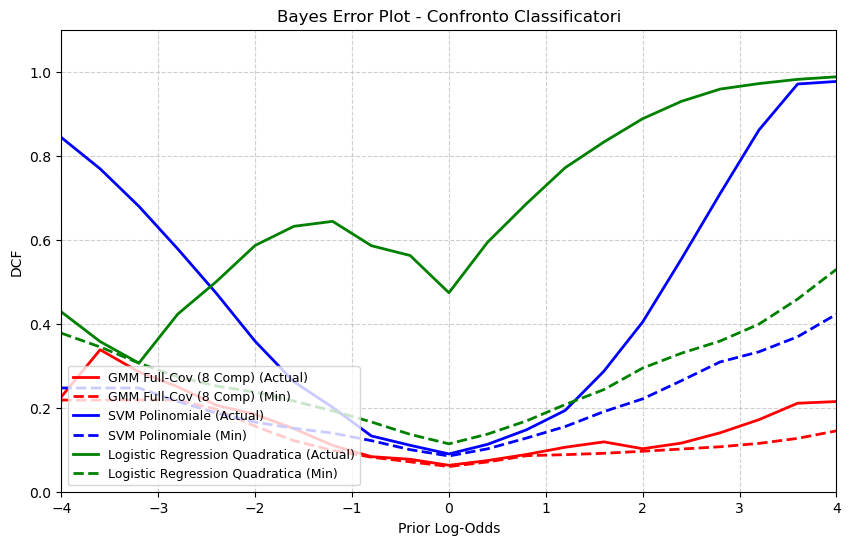

In [30]:
plot_bayes_error(llr_migliori,LVAL)

In [6]:
def extract_kfold_calibrated_scores(S, L, pi_T,KFOLD):
    pooled_scores = []
    pooled_labels = []
    target_log_odds = np.log(pi_T / (1 - pi_T))
    
    # Controlliamo se stiamo facendo Fusione (2D) o singola Calibrazione (1D) (Servirà dopo)
    is_fusion = S.ndim > 1 
    
    for idx in range(KFOLD):
        
        if is_fusion:
            SCAL = np.hstack([S[:, j::KFOLD] for j in range(KFOLD) if j != idx])
            SVAL = S[:, idx::KFOLD]
            SCAL_TRAIN = SCAL # È già 2D
        else:
            SCAL = np.hstack([S[j::KFOLD] for j in range(KFOLD) if j != idx])
            SVAL = S[idx::KFOLD]
            SCAL_TRAIN = SCAL.reshape(1, -1) 
            
        LCAL = np.hstack([L[j::KFOLD] for j in range(KFOLD) if j != idx])
        LVAL = L[idx::KFOLD]
        
        
        v_opt, _ = weighted_trainLogReg(SCAL_TRAIN, LCAL, 0.0, pi_T)
        
        
        if is_fusion:
            alpha = v_opt[0:-1].reshape(-1, 1) # Pesi multipli
            gamma = v_opt[-1] - target_log_odds
            calibrated_SVAL = np.dot(alpha.T, SVAL) + gamma
        else:
            alpha = v_opt[0]                   # Peso singolo
            gamma = v_opt[1] - target_log_odds
            calibrated_SVAL = alpha * SVAL + gamma
            
        pooled_scores.append(calibrated_SVAL.ravel())
        pooled_labels.append(LVAL)
        
    return np.hstack(pooled_scores), np.hstack(pooled_labels)

In [7]:
pi_target=0.5
pi_train_candidates=[0.1,0.2,0.5,0.8,0.9]
calibrated_scores_best = {}

for model_name,raw_scores in llr_migliori.items():
    
    best_act_dcf = float('inf')
    best_pi_train = None
    best_calibrated_scores = None
    print(f"----------------------------{model_name}------------------------------")
    for pi_train in pi_train_candidates:
        cal_scores,pooled_labels=extract_kfold_calibrated_scores(raw_scores,LVAL,pi_train,KFOLD=5)
        pred = get_bayes_decision(cal_scores, pi_target, 1, 1)
        act_dcf = DCF_norm(pred, pooled_labels, pi_target, 1, 1)
        min_dcf = compute_min_dcf(cal_scores, pooled_labels, pi_target, 1, 1)
        print(f"pi_train={pi_train}: minDCF={min_dcf:.3f}, actDCF={act_dcf:.3f}")
    
        if act_dcf < best_act_dcf:
            best_act_dcf = act_dcf
            best_pi_train = pi_train
            best_calibrated_scores = cal_scores

    print(f"Modello migliore {model_name} : pi_train = {best_pi_train} (actDCF: {best_act_dcf:.3f})\n")
    calibrated_scores_best[model_name] = best_calibrated_scores

----------------------------GMM Full-Cov (8 Comp)------------------------------
pi_train=0.1: minDCF=0.060, actDCF=0.064
pi_train=0.2: minDCF=0.060, actDCF=0.063
pi_train=0.5: minDCF=0.060, actDCF=0.063
pi_train=0.8: minDCF=0.060, actDCF=0.062
pi_train=0.9: minDCF=0.060, actDCF=0.061
Modello migliore GMM Full-Cov (8 Comp) : pi_train = 0.9 (actDCF: 0.061)

----------------------------SVM Polinomiale------------------------------
pi_train=0.1: minDCF=0.086, actDCF=0.090
pi_train=0.2: minDCF=0.086, actDCF=0.089
pi_train=0.5: minDCF=0.085, actDCF=0.089
pi_train=0.8: minDCF=0.085, actDCF=0.089
pi_train=0.9: minDCF=0.084, actDCF=0.090
Modello migliore SVM Polinomiale : pi_train = 0.2 (actDCF: 0.089)

----------------------------Logistic Regression Quadratica------------------------------
pi_train=0.1: minDCF=0.112, actDCF=0.114
pi_train=0.2: minDCF=0.113, actDCF=0.113
pi_train=0.5: minDCF=0.113, actDCF=0.113
pi_train=0.8: minDCF=0.114, actDCF=0.115
pi_train=0.9: minDCF=0.114, actDCF=0.115
Mo

Vediamo ora la Point Fusion 

In [52]:
SFUSION_VAL = np.vstack([
    llr_migliori['GMM Full-Cov (8 Comp)'],
    llr_migliori['SVM Polinomiale'],
    llr_migliori['Logistic Regression Quadratica']
])

print("----------------------------Fusione (GMM + SVM + LR)------------------------------")
best_fusion_dcf = float('inf')
best_fusion_pi = None
best_fusion_scores = None

for pi_train in pi_train_candidates:
    
    pooled_fusion_scores, pooled_fusion_labels = extract_kfold_calibrated_scores(SFUSION_VAL, LVAL, pi_train, KFOLD=5)

    
    min_dcf_val_fusion = compute_min_dcf(pooled_fusion_scores, pooled_fusion_labels, pi_target, 1, 1)
    pred_val_fusion = get_bayes_decision(pooled_fusion_scores, pi_target, 1, 1)
    act_dcf_val_fusion = DCF_norm(pred_val_fusion, pooled_fusion_labels, pi_target, 1, 1)

    print(f"pi_train={pi_train}: minDCF={min_dcf_val_fusion:.3f}, actDCF={act_dcf_val_fusion:.3f}")
    
    
    if act_dcf_val_fusion < best_fusion_dcf:
        best_fusion_dcf = act_dcf_val_fusion
        best_fusion_pi = pi_train
        best_fusion_scores = pooled_fusion_scores

print(f"Modello migliore Fusione : pi_train = {best_fusion_pi} (actDCF: {best_fusion_dcf:.3f})\n")

calibrated_scores_best['Fusion (GMM + SVM + LR)'] = best_fusion_scores

----------------------------Fusione (GMM + SVM + LR)------------------------------
pi_train=0.1: minDCF=0.060, actDCF=0.063
pi_train=0.2: minDCF=0.057, actDCF=0.062
pi_train=0.5: minDCF=0.060, actDCF=0.062
pi_train=0.8: minDCF=0.060, actDCF=0.063
pi_train=0.9: minDCF=0.060, actDCF=0.063
Modello migliore Fusione : pi_train = 0.2 (actDCF: 0.062)



Parte dell'evaluation

In [25]:
#Carichiamo l'intero set di training
dataset_train = np.loadtxt('../trainData.txt', delimiter=',')
D_TRAIN_ALL = dataset_train[:, :6].T
L_TRAIN_ALL = dataset_train[:, 6]

#Carichiamo l'evaluation set
evalData = np.loadtxt('../evalData.txt', delimiter=',')
D_eval=evalData[:,:6].T
L_eval=evalData[:,6]



Importiamo dal notebook 7 le funzioni SVM

In [10]:
def getRow(vet):
    return vet.reshape((1, vet.size))
def getCol(vet):
     return vet.reshape((vet.size, 1))
def getMu(D):
    return D.sum(axis=1)/D.shape[1]

def KRB(D1, D2, gamma):
    # Calcolo delle norme al quadrato delle colonne per il primo dataset
    # Il reshape(-1, 1) assicura che il risultato sia un vettore colonna
    D1_norm2 = (D1 ** 2).sum(axis=0).reshape(-1, 1)
    
    # Calcolo delle norme al quadrato delle colonne per il secondo dataset
    # Il reshape(1, -1) assicura che il risultato sia un vettore riga
    D2_norm2 = (D2 ** 2).sum(axis=0).reshape(1, -1)
    
    # Calcolo della matrice delle distanze al quadrato sfruttando il broadcasting
    dist2 = D1_norm2 + D2_norm2 - 2 * (D1.T @ D2)
    
    # Applicazione dell'esponenziale scalato per gamma
    return np.exp(-gamma * dist2)

def regular_kernel(kernel,xi):
    return kernel+xi

def train_kernel_KRB(K, C, DTR, LTR,xi,gamma):
    N = DTR.shape[1]
    ZTR = LTR * 2 - 1
    
    
    kernel_reg=regular_kernel(KRB(DTR,DTR,gamma),xi)
    
    H = getCol(ZTR) * getRow(ZTR) * kernel_reg

    def fOpt(alpha):
        Ha = H @ alpha
        loss = 0.5 * alpha.T @ Ha - alpha.sum()
        grad = Ha - np.ones(alpha.size)
        return loss, grad

    x0 = np.zeros(N)
    alpha, _, _ = scipy.optimize.fmin_l_bfgs_b(
        func=fOpt,
        x0=x0,
        approx_grad=False,
        bounds=[(0, C) for _ in range(N)],
        factr=np.nan,
        pgtol=1e-5
    )
    
    
    dual_loss,_=fOpt(alpha)
    primal_loss=0.5*alpha.T @(H@alpha)+C*np.maximum(0,1-H@alpha).sum()
    print(f"Primal Loss : {primal_loss} - Dual Loss : {-dual_loss}")
    return alpha

Importiamo le funzioni per la Logistic Regression

In [18]:
def expand_features(D):
    n_features = D.shape[0]
    n_samples = D.shape[1]
    
    # La nuova dimensionalità sarà data dal quadrato delle feature originali (xx^T)
    # sommato al numero delle feature originali (x)
    expanded_D = np.zeros((n_features**2 + n_features, n_samples))
    
    for i in range(n_samples):
        # Estrazione del singolo campione come vettore colonna
        x = D[:, i:i+1]
        
        # Calcolo della matrice dei prodotti incrociati
        xxT = np.dot(x, x.T)
        
        # Vettorizzazione della matrice e concatenazione con il termine lineare
        phi_x = np.vstack([xxT.reshape(-1, 1), x])
        
        # Inserimento del campione espanso nella nuova matrice
        expanded_D[:, i:i+1] = phi_x
        
    return expanded_D
def trainLogReg(DTR,LTR,l):
    ZTR=2*LTR-1
    n=DTR.shape[1]

    def logreg_obj(v):
        w,b=v[0:-1],v[-1]
        w=w.reshape(-1,1)
        S=(np.dot(w.T,DTR)+b).ravel()
        loss_terms=np.logaddexp(0,-ZTR*S)
        J=(l/2)*np.linalg.norm(w)**2+np.mean(loss_terms)
        G=-ZTR/(1.0 + np.exp(ZTR*S))
        #gradienti
        grad_w=l*w.ravel()+np.mean(G*DTR,axis=1)
        grad_b=np.mean(G)
        v_grad=np.hstack([grad_w,grad_b])
        return J,v_grad
    
    x0 = np.zeros(DTR.shape[0]+1) #??perchè
    xf,f_min,d=scipy.optimize.fmin_l_bfgs_b(logreg_obj,x0=x0,approx_grad=False)

    return xf,f_min

Importiamo le funzioni per il GMM

In [12]:
def logpdf_GAU_ND(x, mu, C):
    M=x.shape[0]
    XC = x - mu
    sign, logdet = np.linalg.slogdet(C)
    invC = np.linalg.inv(C)
    quad = np.sum(XC * (invC @ XC), axis=0)
    return -0.5 * (M * np.log(2*np.pi) + logdet + quad)


def logpdf_GMM(X,gmm):
    n_cluster=len(gmm)
    S=np.zeros((n_cluster,X.shape[1]))
    
    for g in range(n_cluster):
        w=gmm[g][0]
        mu=gmm[g][1]
        C=gmm[g][2]
        S[g, :] = logpdf_GAU_ND(X, mu, C) + np.log(w)
    
    logdens = scipy.special.logsumexp(S, axis=0)
    return S,logdens
def EM_constrained(threshold,X,gmm,psi):
    
    actual_gmm=gmm
    N=X.shape[1]
    
    #E Step
    # Calcolo la probabilità a posteriori (responsability) con logpdf_GMM(X,gmm)
    S, logdens = logpdf_GMM(X, actual_gmm)
    ll_actual = np.mean(logdens) #Ci servirà dopo per le stop criterion
    
    while True:
    # Calcolo la probabilità a posteriori (responsability) con logpdf_GMM(X,gmm)
        gamma = np.exp(S - logdens)
        new_gmm=[]

        for g in range(len(actual_gmm)):
            gamma_g=gamma[g,:]

            Zg=np.sum(gamma_g)
            # Fg diventa un vettore colonna D x 1 grazie a keepdims=True
            Fg=np.sum(X*gamma_g,axis=1,keepdims=True)
            # Sg è la matrice D x D ottenuta dal prodotto della matrice pesata per la sua trasposta
            Sg=(X*gamma_g) @ X.T

            #Aggiorno i parametri
            new_mu = Fg / Zg
            new_cov = Sg / Zg - (new_mu @ new_mu.T)
            new_w = Zg / N

            #Applichiamo il vincolo
            U, s, _ = np.linalg.svd(new_cov)
            s[s<psi] = psi
            new_cov = np.dot(U, getCol(s)*U.T)
            
            new_gmm.append((new_w, new_mu, new_cov))
        
        #Controllo gli stop criterion
        S_new,new_logdens=logpdf_GMM(X,new_gmm)
        ll_new=np.mean(new_logdens)
        delta=ll_new-ll_actual

        if delta<=threshold:
            actual_gmm=new_gmm
            break

        actual_gmm=new_gmm
        S=S_new
        logdens=new_logdens
        ll_actual=ll_new
    return actual_gmm

def split_gmm(gmm,alpha=0.1):
    new_gmm=[]

    for w,mu,cov in gmm:
        new_w=w/2
        U, s, Vh = np.linalg.svd(cov)
        d = U[:, 0:1] * s[0]**0.5 * alpha
        new_mu1=mu-d
        new_mu2=mu+d
        new_gmm.append((new_w,new_mu1,cov))
        new_gmm.append((new_w,new_mu2,cov))

    return new_gmm

def LBG_constrained(X,threshold,target_components,alpha=0.1,psi=0.01):
    mu_global=np.mean(X,axis=1,keepdims=True)
    cov_global = ((X - mu_global) @ (X - mu_global).T) / X.shape[1]
    GMM_1 = [(1.0, mu_global, cov_global)]

    gmm=EM_constrained(threshold,X,GMM_1,psi) #serve a stabilizzare la loglikelihood

    current_components=1

    while current_components<target_components:
        #sdoppiamento
        gmm=split_gmm(gmm,alpha)
        gmm=EM_constrained(threshold,X,gmm,psi)
        current_components*=2
    
    return gmm

In [14]:
def best_LR(DTR,LTR,DVAL):
    DTR_quad = expand_features(DTR)
    DVAL_quad = expand_features(DVAL)
    pi_T=0.1
    target_prior_log_odds=np.log(pi_T/(1-pi_T))
    l=0.03162277660168379
    v_opt,J_min=trainLogReg(DTR_quad,LTR,l)
    w_opt=v_opt[:-1]
    b_opt=v_opt[-1]
    S_val=np.dot(w_opt.T,DVAL_quad)+b_opt
    LP=(S_val>0).astype(int)
    score_lr_quad=S_val-target_prior_log_odds
    return score_lr_quad

def best_SVM(DTR,LTR,DVAL):
    d=2
    xi=1
    pi_T=0.1
    K=0
    c=31.622776601683793
    g=0.1353352832366127
    ZTR=LTR*2-1
    alpha=train_kernel_KRB(K, c, DTR, LTR, xi, g)
    reg_kernel=regular_kernel(KRB(DTR, DVAL, g), xi)
    score_svm_poly=alpha*ZTR @ reg_kernel
    return score_svm_poly

def best_GMM(DTR,LTR,DVAL):
    DTR0 = DTR[:, LTR == 0]
    DTR1 = DTR[:, LTR == 1]
    gmm0 = LBG_constrained(DTR0, threshold=1e-6, target_components=8, alpha=0.1, psi=0.01)
    gmm1 = LBG_constrained(DTR1, threshold=1e-6, target_components=8, alpha=0.1, psi=0.01)
    _, logdens0 = logpdf_GMM(DVAL, gmm0)   
    _, logdens1 = logpdf_GMM(DVAL, gmm1)
    llr = logdens1 - logdens0
    return llr

Ora estraiamo gli scores utilizzando queste 3 ultime funzioni

In [19]:
eval_raw_gmm=best_GMM(D_TRAIN_ALL,L_TRAIN_ALL,D_eval)
eval_raw_SVM=best_SVM(D_TRAIN_ALL,L_TRAIN_ALL,D_eval)
eval_raw_lr=best_LR(D_TRAIN_ALL,L_TRAIN_ALL,D_eval)

Primal Loss : 17455.723890350684 - Dual Loss : 17455.675491324997


In [50]:

systems = {
    'GMM raw': eval_raw_gmm,
    'SVM raw': eval_raw_SVM,
    'LR raw': eval_raw_lr,
}

print(f"=== Evaluation dataset - raw scores (pi_T = {pi_target}) ===")
for name, scores in systems.items():
    min_dcf = compute_min_dcf(scores, L_eval, pi_target, 1, 1)
    pred = get_bayes_decision(scores, pi_target, 1, 1)
    act_dcf = DCF_norm(pred, L_eval, pi_target, 1, 1)
    print(f"{name} -> minDCF: {min_dcf:.3f}, actDCF: {act_dcf:.3f}")#Prendiamo gli score che i modelli hanno fatto sul Validation e sull'Evaluation


=== Evaluation dataset - raw scores (pi_T = 0.5) ===
GMM raw -> minDCF: 0.071, actDCF: 0.074
SVM raw -> minDCF: 0.092, actDCF: 0.095
LR raw -> minDCF: 0.142, actDCF: 0.490


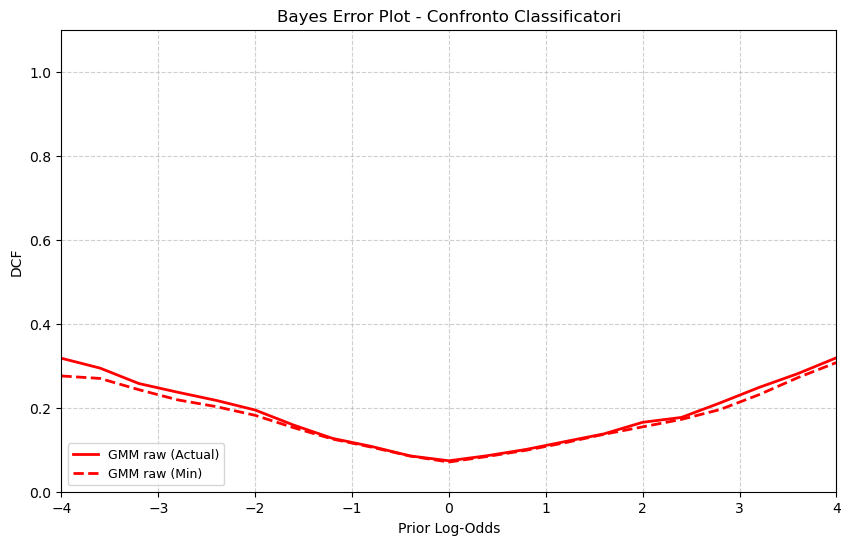

In [ ]:
plot_bayes_error({'GMM raw': eval_raw_gmm}, L_eval)

In [20]:
pi_target=0.5
target_log_odds=np.log(pi_target/(1-pi_target))
def calibrate_scores(SCAL, LCAL, SVAL, pi_train, pi_target):
    SCAL_2D = SCAL.reshape(1, -1) # otteniamo (1,N) per darlo in pasto alla funzione logReg

    # Addestriamo la LR usando il pi_train ottimale trovato in validazione
    l_reg = 0.0
    v_opt, _ = weighted_trainLogReg(SCAL_2D, LCAL, l_reg, pi_train)

    alpha = v_opt[0] # w
    beta = v_opt[1]  # b

    # Calcoliamo il target_log_odds dinamicamente usando il prior dell'applicazione
    target_log_odds = np.log(pi_target / (1 - pi_target))
    gamma = beta - target_log_odds

    calibrated_SVAL = alpha * SVAL + gamma

    return calibrated_SVAL, alpha, gamma

eval_cal_gmm, _, _ = calibrate_scores(llr_migliori['GMM Full-Cov (8 Comp)'], LVAL, eval_raw_gmm, 0.9, pi_target)

# SVM (con pi_train ottimale = 0.2)
eval_cal_svm, _, _ = calibrate_scores(llr_migliori['SVM Polinomiale'], LVAL, eval_raw_SVM, 0.2, pi_target)

# LR (con pi_train ottimale = 0.2)
eval_cal_lr, _, _ = calibrate_scores(llr_migliori['Logistic Regression Quadratica'], LVAL, eval_raw_lr, 0.2, pi_target)

In [26]:

systems = {
    'GMM calibrato': eval_cal_gmm,
    'SVM calibrato': eval_cal_svm,
    'LR calibrato': eval_cal_lr,
}

print(f"=== Evaluation dataset - Calibrated scores (pi_T = {pi_target}) ===")
for name, scores in systems.items():
    min_dcf = compute_min_dcf(scores, L_eval, pi_target, 1, 1)
    pred = get_bayes_decision(scores, pi_target, 1, 1)
    act_dcf = DCF_norm(pred, L_eval, pi_target, 1, 1)
    print(f"{name} -> minDCF: {min_dcf:.3f}, actDCF: {act_dcf:.3f}")#Prendiamo gli score che i modelli hanno fatto sul Validation e sull'Evaluation



=== Evaluation dataset - Calibrated scores (pi_T = 0.5) ===
GMM calibrato -> minDCF: 0.071, actDCF: 0.114
SVM calibrato -> minDCF: 0.092, actDCF: 0.120
LR calibrato -> minDCF: 0.142, actDCF: 0.173


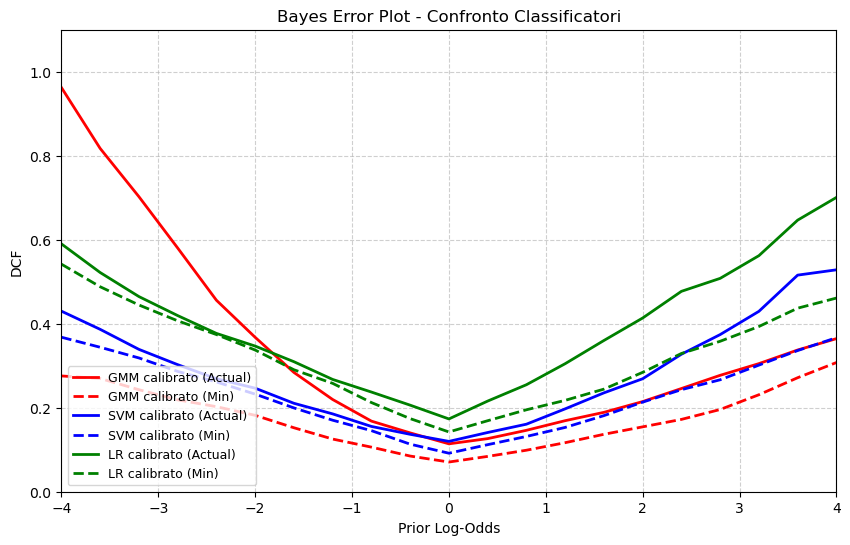

In [46]:
plot_bayes_error(systems,L_eval)

In [41]:
SFUSION_VAL = np.vstack([
    llr_migliori['GMM Full-Cov (8 Comp)'], 
    llr_migliori['SVM Polinomiale'], 
    llr_migliori['Logistic Regression Quadratica']
])

SFUSION_EVAL = np.vstack([eval_raw_gmm, eval_raw_SVM, eval_raw_lr])

v_opt_fus,_=weighted_trainLogReg(SFUSION_VAL,LVAL,0.0,0.2)
#Estraiamo i pesi
alpha_fus = v_opt_fus[0:-1].reshape(-1, 1)
gamma_fus = v_opt_fus[-1] - target_log_odds
#Calcoliamo il punto di fusione 
eval_cal_fusion = (np.dot(alpha_fus.T, SFUSION_EVAL) + gamma_fus).ravel()

In [45]:
min_dcf = compute_min_dcf(eval_cal_fusion, L_eval, pi_target, 1, 1)
pred = get_bayes_decision(eval_cal_fusion, pi_target, 1, 1)
act_dcf = DCF_norm(pred, L_eval, pi_target, 1, 1)
print(f"Score fusion GMM + SVM + LR -> minDCF: {min_dcf:.3f}, actDCF: {act_dcf:.3f}")#Prendiamo gli score che i modelli hanno fatto sul Validation e sull'Evaluation
error_rate = np.mean(pred != L_eval)
print(f"Error rate: {error_rate:.3f}")

Score fusion GMM + SVM + LR -> minDCF: 0.072, actDCF: 0.090
Error rate: 0.045


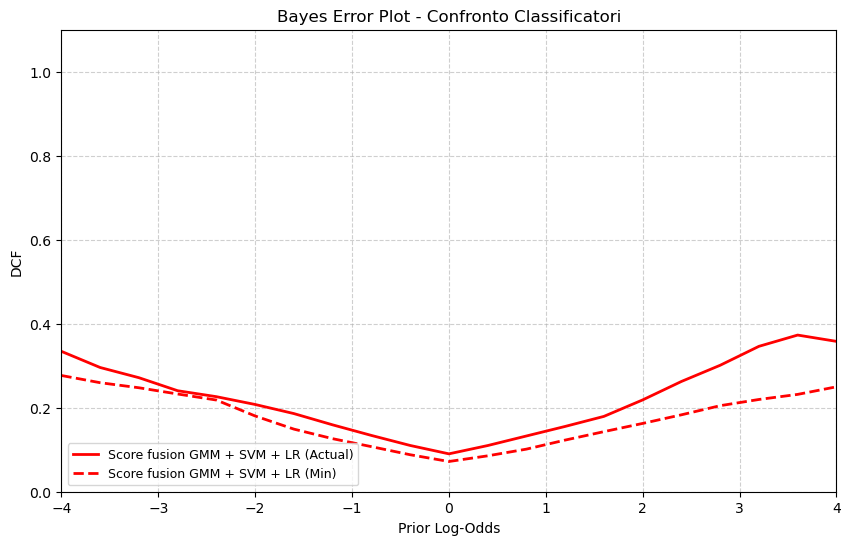

In [47]:
plot_bayes_error({"Score fusion GMM + SVM + LR":eval_cal_fusion},L_eval)